# 2025AD05029 Bank Marketing — Assignment 2

M.Tech (AIML/DSE) — Machine Learning — Assignment 2

This notebook trains and evaluates 5 classification models on the UCI
**Bank Marketing** dataset
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Gaussian Naive Bayes
5. Random Forest (Ensemble)

For each model we have computed: **Accuracy, AUC, Precision, Recall, F1, MCC**,
and saved the fitted pipelines (`.pkl`) plus a held-out `test_data.csv` for Streamlit app.


## 1. Install / import libraries

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn ucimlrepo

import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, precision_score,
    recall_score, roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

import os
os.makedirs("model", exist_ok=True)

## 2. Loading the dataset

In [2]:
from ucimlrepo import fetch_ucirepo

try:
    bank_marketing = fetch_ucirepo(id=222)
    X_raw = bank_marketing.data.features
    y_raw = bank_marketing.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    print("Fetched directly from UCI Machine Learning Repository (id=222)")
except Exception as e:
    print(f"Could not reach UCI ({e}); falling back to local CSV.")
    df = pd.read_csv("bank_marketing.csv", sep=";")

print(df.shape)
df.head()

Fetched directly from UCI Machine Learning Repository (id=222)
(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 3. Explore the data

In [3]:
df.info()
print()
print(df['y'].value_counts())
print()
print("Missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

y
no     39922
yes     5289
Name: count, dtype: int64

Missi

## 4. Preprocessing

In [4]:
# Drop 'duration' - known data leakage feature (see intro note above)
df = df.drop(columns=["duration"])

TARGET = "y"
df[TARGET] = df[TARGET].map({"yes": 1, "no": 0})

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

test_export = X_test.copy()
test_export[TARGET] = y_test.values
test_export.to_csv("test_data.csv", index=False)
print("Saved test_data.csv with", len(test_export), "rows")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

Numeric features: ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Saved test_data.csv with 9043 rows


## 5. Define the 5 models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    "kNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=RANDOM_STATE
    ),
}

## 6. Train, evaluate, and save each model

In [6]:
results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }
    results.append(metrics)
    fitted_pipelines[name] = pipe

    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    with open(f"model/{safe_name}.pkl", "wb") as f:
        pickle.dump(pipe, f)

    print(f"\n{name}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k}: {v:.4f}")

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df.to_csv("model/metrics_comparison.csv")

schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": TARGET,
}
with open("model/schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("\nAll models trained and saved to model/ folder.")


Logistic Regression
  Accuracy: 0.8933
  AUC: 0.7717
  Precision: 0.6632
  Recall: 0.1786
  F1: 0.2815
  MCC: 0.3065

Decision Tree
  Accuracy: 0.8909
  AUC: 0.7137
  Precision: 0.5903
  Recall: 0.2193
  F1: 0.3198
  MCC: 0.3139

kNN
  Accuracy: 0.8907
  AUC: 0.7104
  Precision: 0.6006
  Recall: 0.1975
  F1: 0.2973
  MCC: 0.3010

Naive Bayes
  Accuracy: 0.8452
  AUC: 0.7514
  Precision: 0.3708
  Recall: 0.4641
  F1: 0.4123
  MCC: 0.3271

Random Forest (Ensemble)
  Accuracy: 0.8943
  AUC: 0.8004
  Precision: 0.6889
  Recall: 0.1758
  F1: 0.2801
  MCC: 0.3121

All models trained and saved to model/ folder.


## 7. Comparison table

In [7]:
results_df.style.highlight_max(axis=0, color="#c6f6d5")

,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
Logistic Regression,0.893300,0.771700,0.663200,0.178600,0.281500,0.306500
Decision Tree,0.890900,0.713700,0.590300,0.219300,0.319800,0.313900
kNN,0.890700,0.710400,0.600600,0.197500,0.297300,0.301000
Naive Bayes,0.845200,0.751400,0.370800,0.464100,0.412300,0.327100
Random Forest (Ensemble),0.894300,0.800400,0.688900,0.175800,0.280100,0.312100


## 8. Visualize: metric comparison bar chart

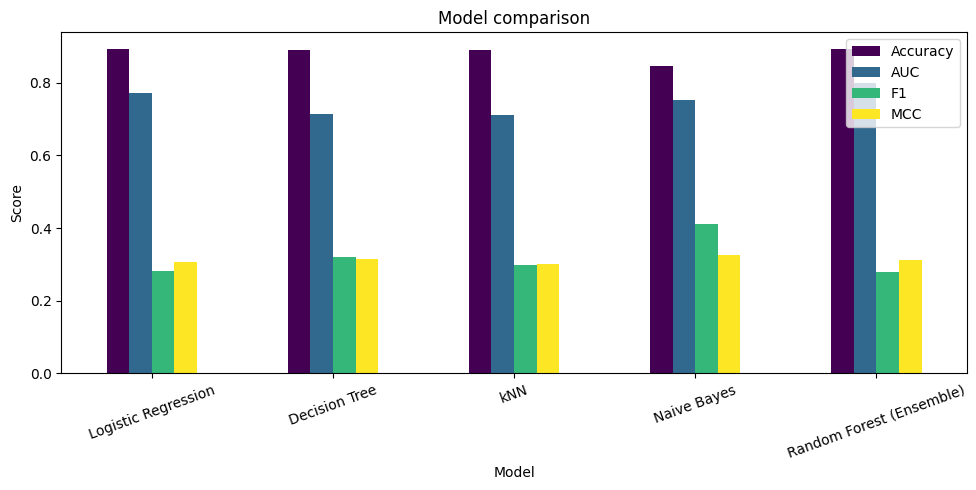

In [8]:
results_df[["Accuracy", "AUC", "F1", "MCC"]].plot(
    kind="bar", figsize=(10, 5), rot=20, colormap="viridis"
)
plt.title("Model comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 9. Confusion matrices for all 5 models

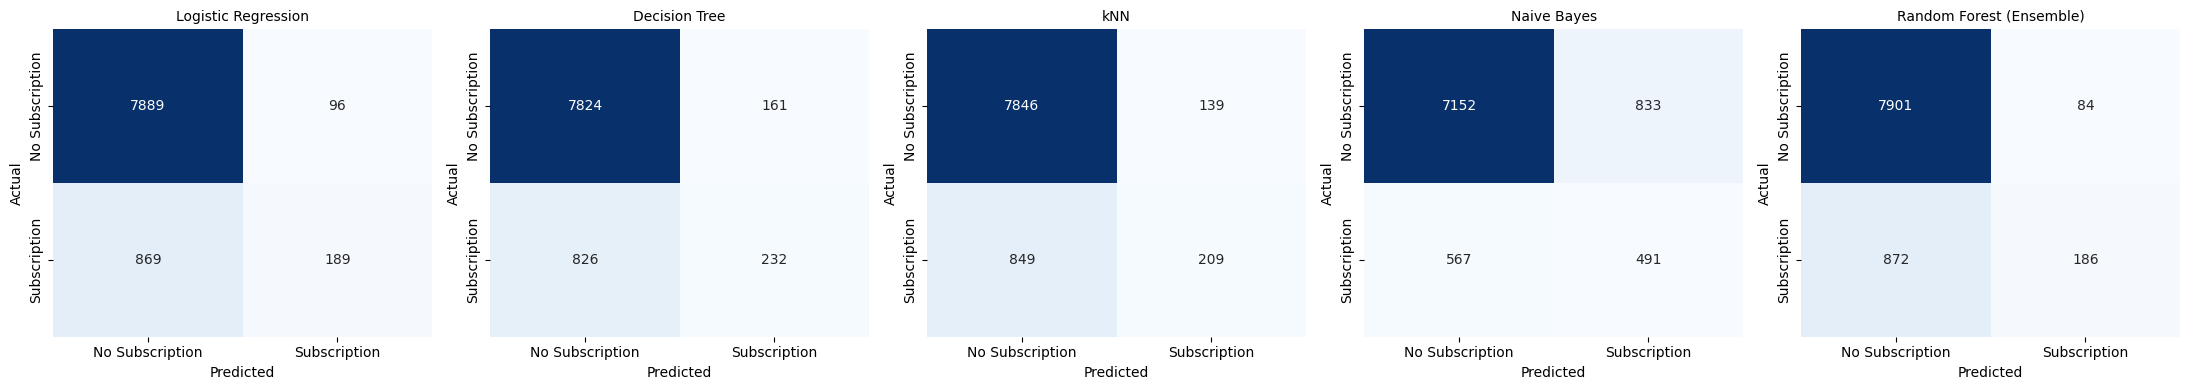

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Subscription", "Subscription"],
                yticklabels=["No Subscription", "Subscription"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 10. Download artifacts (Colab only)

Zips up the `model/` folder + `test_data.csv` so you can download them
and push to your GitHub repo alongside `app.py`.

In [10]:
import shutil

shutil.make_archive("assignment2_artifacts", "zip", ".", "model")

try:
    from google.colab import files
    files.download("assignment2_artifacts.zip")
    files.download("test_data.csv")
except ImportError:
    print("Not running in Colab — files are already saved locally in this folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>